In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../screenshots", exist_ok=True)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw_repos.csv")
print(df.shape)

(5999, 13)


In [3]:
df.info()
df.describe()
df.isna().sum()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5999 entries, 0 to 5998
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   JonathonReinhart/scuba                      5999 non-null   str  
 1   Python                                      5996 non-null   str  
 2   1077                                        5999 non-null   int64
 3   19                                          5999 non-null   int64
 4   31                                          5999 non-null   int64
 5   2015-09-28T05:35:54Z                        5999 non-null   str  
 6   2026-01-26T04:03:05Z                        5999 non-null   str  
 7   build-tool,docker                           3928 non-null   str  
 8   MIT                                         5142 non-null   str  
 9   Simple Container-Utilizing Build Apparatus  5793 non-null   str  
 10  True                                        599

,JonathonReinhart/scuba,Python,1077,19,31,2015-09-28T05:35:54Z,2026-01-26T04:03:05Z,"build-tool,docker",MIT,Simple Container-Utilizing Build Apparatus,True,False,99
0,charleshberlin/O-RLY-Book-Generator,Python,2049,19,5,2016-04-22T19:01:18Z,2016-04-22T20:05:34Z,NaN,MIT,Python tool for generating O RLY? Book Covers,True,False,99
1,stevenseeley/heaper,Python,370,32,0,2012-01-03T15:40:24Z,2012-10-03T08:18:36Z,NaN,NaN,"heaper, an advanced heap analysis plugin for I...",True,False,99
2,amplab/benchmark,Python,58803,64,10,2013-06-04T14:23:29Z,2016-04-05T18:49:31Z,NaN,NaN,Large scale query engine benchmark,True,False,99
3,xiaoyufenfei/ESNet,Python,1059,9,3,2019-05-05T01:16:04Z,2024-07-25T10:16:26Z,"cityscape-dataset,computer-vision,esnet,pytorc...",MIT,ESNet: An Efficient Symmetric Network for Real...,True,False,99
4,iamhellaweiri/EXPLOIT-FRAMEWORK-v1.0,Python,12,13,6,2020-12-28T09:08:38Z,2020-12-29T08:57:05Z,NaN,NaN,EXPLOIT-FRAMEWORK is a very powerfull hacking ...,True,False,99


In [4]:
cols = ["full_name","language","size","forks_count","open_issues_count",
        "created_at","pushed_at","topics","license","description",
        "has_wiki","has_pages","stargazers_count"]
df = pd.read_csv("../data/raw_repos.csv", names=cols, header=None)

In [5]:
print(df.columns.tolist())
print(df.shape)
df.head(3)

['full_name', 'language', 'size', 'forks_count', 'open_issues_count', 'created_at', 'pushed_at', 'topics', 'license', 'description', 'has_wiki', 'has_pages', 'stargazers_count']
(6000, 13)


,full_name,language,size,forks_count,open_issues_count,created_at,pushed_at,topics,license,description,has_wiki,has_pages,stargazers_count
0,JonathonReinhart/scuba,Python,1077,19,31,2015-09-28T05:35:54Z,2026-01-26T04:03:05Z,"build-tool,docker",MIT,Simple Container-Utilizing Build Apparatus,True,False,99
1,charleshberlin/O-RLY-Book-Generator,Python,2049,19,5,2016-04-22T19:01:18Z,2016-04-22T20:05:34Z,NaN,MIT,Python tool for generating O RLY? Book Covers,True,False,99
2,stevenseeley/heaper,Python,370,32,0,2012-01-03T15:40:24Z,2012-10-03T08:18:36Z,NaN,NaN,"heaper, an advanced heap analysis plugin for I...",True,False,99


In [6]:
print(df.duplicated(subset="full_name").sum())
df = df.drop_duplicates(subset="full_name")

0


In [7]:
df["language"] = df["language"].fillna("Other")
df["description"] = df["description"].fillna("")
df["topics"] = df["topics"].fillna("")
df["license"] = df["license"].fillna("")

In [8]:
today = pd.Timestamp.now(tz="UTC")

df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
df["pushed_at"]  = pd.to_datetime(df["pushed_at"], utc=True)

df["age_days"]        = (today - df["created_at"]).dt.days
df["days_since_push"] = (today - df["pushed_at"]).dt.days

In [9]:
# topics_count: adapt to how topics is stored
import ast
def count_topics(x):
    if not x or x == "[]":
        return 0
    if x.startswith("["):
        return len(ast.literal_eval(x))      # "['a','b']" format
    return len(x.split("|"))                 # change "|" to "," if needed

df["topics_count"] = df["topics"].apply(count_topics)

df["has_license"] = (df["license"].astype(str).str.strip() != "").astype(int)
df["has_license"] = (~df["license"].isin(["", "None", "none"])).astype(int)  # use whichever fits your data

df["description_length"] = df["description"].str.len()
df["has_wiki"]  = df["has_wiki"].astype(int)
df["has_pages"] = df["has_pages"].astype(int)
df["size_kb"]   = df["size"]

In [10]:
df[["age_days","days_since_push","topics_count","has_license",
    "description_length","has_wiki","has_pages","size_kb"]].describe()

,age_days,days_since_push,topics_count,has_license,description_length,has_wiki,has_pages,size_kb
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03
mean,2795.929500,668.273667,0.654833,0.857167,74.654667,0.663167,0.198167,1.385951e+05
std,1559.182194,999.679621,0.475462,0.349932,94.736263,0.472667,0.398652,7.796619e+05
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1526.750000,4.000000,0.000000,1.000000,37.000000,0.000000,0.000000,1.046750e+03
50%,2845.500000,125.000000,1.000000,1.000000,58.000000,1.000000,0.000000,8.701500e+03
75%,3967.250000,1006.000000,1.000000,1.000000,92.000000,1.000000,0.000000,5.744650e+04
max,6721.000000,6026.000000,1.000000,1.000000,5835.000000,1.000000,1.000000,3.620302e+07


In [11]:
def make_label(stars):
    if stars < 100:
        return "Low"
    elif stars < 1000:
        return "Medium"
    else:
        return "High"

df["popularity"] = df["stargazers_count"].apply(make_label)
df["popularity"].value_counts()

popularity
High      2001
Low       2000
Medium    1999
Name: count, dtype: int64

In [12]:
print(df.groupby("popularity")["stargazers_count"].agg(["min", "max"]))

             min     max
popularity              
High        1000  485761
Low           95      99
Medium       815     999


In [13]:
feature_cols = ["language","size_kb","forks_count","open_issues_count",
                "age_days","days_since_push","topics_count","has_license",
                "description_length","has_wiki","has_pages"]

clean = df[["full_name"] + feature_cols + ["popularity"]].copy()

In [14]:
print(clean.isna().sum().sum())   # must be 0
print(clean.shape)
clean.head()

0
(6000, 13)


,full_name,language,size_kb,forks_count,open_issues_count,age_days,days_since_push,topics_count,has_license,description_length,has_wiki,has_pages,popularity
0,JonathonReinhart/scuba,Python,1077,19,31,4025,252,1,1,42,1,0,Low
1,charleshberlin/O-RLY-Book-Generator,Python,2049,19,5,3817,3817,0,1,45,1,0,Low
2,stevenseeley/heaper,Python,370,32,0,5388,5115,0,0,63,1,0,Low
3,amplab/benchmark,Python,58803,64,10,4870,3834,0,0,34,1,0,Low
4,xiaoyufenfei/ESNet,Python,1059,9,3,2710,802,1,1,73,1,0,Low


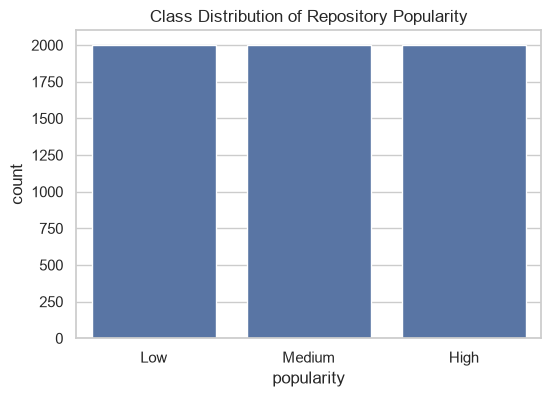

In [15]:
plt.figure(figsize=(6,4))
order = ["Low","Medium","High"]
sns.countplot(data=clean, x="popularity", order=order)
plt.title("Class Distribution of Repository Popularity")
plt.savefig("../screenshots/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

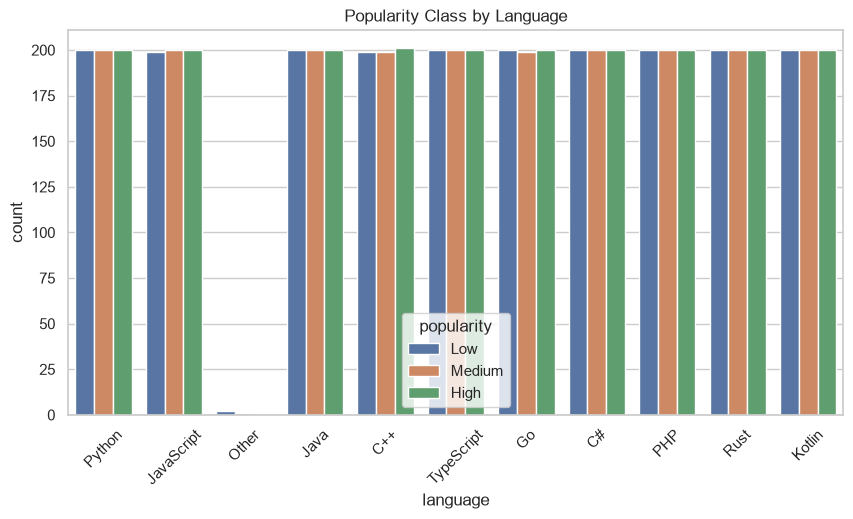

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=clean, x="language", hue="popularity", hue_order=order)
plt.xticks(rotation=45)
plt.title("Popularity Class by Language")
plt.savefig("../screenshots/02_class_by_language.png", dpi=150, bbox_inches="tight")
plt.show()

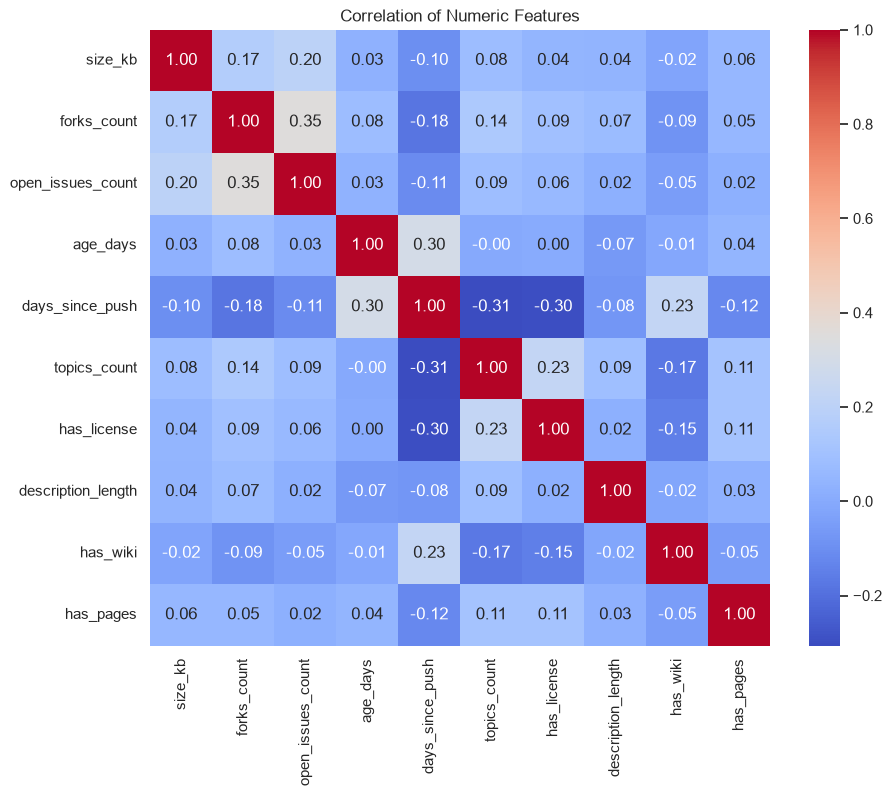

In [17]:
num_cols = ["size_kb","forks_count","open_issues_count","age_days",
            "days_since_push","topics_count","has_license",
            "description_length","has_wiki","has_pages"]
plt.figure(figsize=(10,8))
sns.heatmap(clean[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation of Numeric Features")
plt.savefig("../screenshots/03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

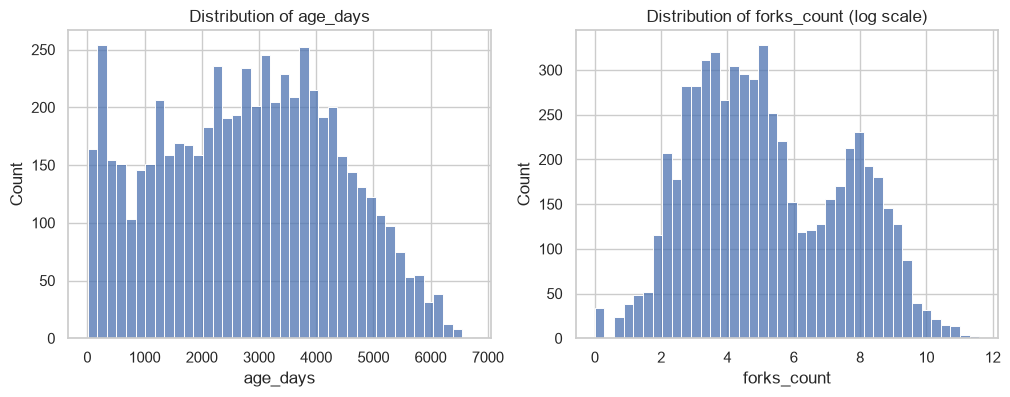

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(clean["age_days"], bins=40, ax=ax[0])
ax[0].set_title("Distribution of age_days")
sns.histplot(np.log1p(clean["forks_count"]), bins=40, ax=ax[1])
ax[1].set_title("Distribution of forks_count (log scale)")
plt.savefig("../screenshots/04_age_forks_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

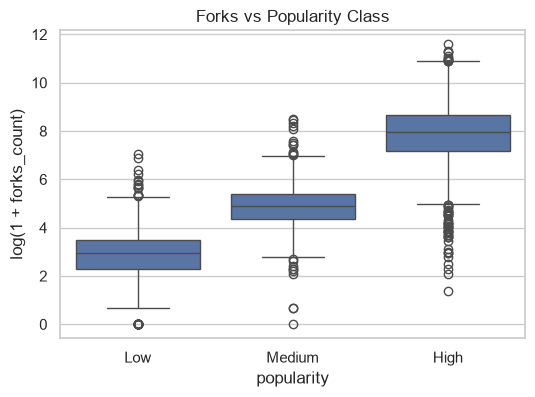

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(data=clean, x="popularity", y=np.log1p(clean["forks_count"]), order=order)
plt.ylabel("log(1 + forks_count)")
plt.title("Forks vs Popularity Class")
plt.savefig("../screenshots/05_forks_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
clean.to_csv("../data/clean_repos.csv", index=False)
print(pd.read_csv("../data/clean_repos.csv").shape)

(6000, 13)


In [21]:
# 1. Class distribution
print(clean["popularity"].value_counts(), "\n")

# 2. Language vs class (share of High within each language)
lang_tab = pd.crosstab(clean["language"], clean["popularity"], normalize="index").round(2)
print(lang_tab.sort_values("High", ascending=False), "\n")

# 3. Correlations (strongest pairs, ignoring the diagonal)
corr = clean[num_cols].corr()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(6), "\n")

# 4. Medians by class (shows what separates Low / Medium / High)
print(clean.groupby("popularity")[["forks_count","age_days","days_since_push",
      "topics_count","description_length","open_issues_count","size_kb"]].median().loc[["Low","Medium","High"]], "\n")

# 5. Share with license / wiki / pages by class
print(clean.groupby("popularity")[["has_license","has_wiki","has_pages"]].mean().round(2).loc[["Low","Medium","High"]], "\n")

# 6. Skewness
print("skew age_days:", round(clean["age_days"].skew(), 2))
print("skew forks_count:", round(clean["forks_count"].skew(), 2))

popularity
High      2001
Low       2000
Medium    1999
Name: count, dtype: int64 

popularity  High   Low  Medium
language                      
C++         0.34  0.33    0.33
C#          0.33  0.33    0.33
Go          0.33  0.33    0.33
Java        0.33  0.33    0.33
JavaScript  0.33  0.33    0.33
Kotlin      0.33  0.33    0.33
PHP         0.33  0.33    0.33
Rust        0.33  0.33    0.33
Python      0.33  0.33    0.33
TypeScript  0.33  0.33    0.33
Other       0.00  0.67    0.33 

forks_count      open_issues_count    0.353736
days_since_push  topics_count        -0.306707
                 has_license         -0.299105
age_days         days_since_push      0.299077
days_since_push  has_wiki             0.228942
topics_count     has_license          0.226620
dtype: float64 

            forks_count  age_days  days_since_push  topics_count  \
popularity                                                         
Low                18.0    2367.0            735.5           0.0   
Medium  

## Observations from EDA

1. **Class distribution.** The dataset is balanced, with about 2,000 repositories
   in each class (High 2001, Low 2000, Medium 1999). This comes from the
   sampling design (equal queries per star range), not from GitHub's natural
   distribution, so random guessing would be right about 33% of the time.

2. **Forks and issues rise steeply with popularity.** Median forks_count is 18
   for Low, 131 for Medium and 2,840 for High, and median open issues goes
   from 3 to 17 to 186. These are the clearest separators between the classes.
   forks_count is extremely right-skewed (skew = 7.59), so a log scale was used
   for plotting, whereas age_days is almost symmetric (skew = 0.03).

3. **Popular repositories are actively maintained.** The median High repository
   was pushed 3 days ago, compared with 263 days for Medium and 734 days for
   Low. High repositories are also older (median 3,327 days vs 2,366 for Low),
   which suggests popularity builds up over time but only for projects that
   keep being updated.

4. **Documentation and metadata signals.** The share of repositories with a
   license rises from 74% (Low) to 88% (Medium) to 96% (High), and the share
   with GitHub Pages rises from 12% to 20% to 28%. Median size_kb also grows
   from about 1.5 MB to 5.4 MB to 57 MB, so larger projects tend to be more
   popular. Surprisingly, has_wiki goes the other way, falling from 78% (Low) to
   53% (High), possibly because well-known projects use external documentation
   sites instead of the GitHub wiki.

5. **Correlations are weak in pairs.** The strongest correlation is
   forks_count with open_issues_count (r = 0.35), and all other pairs are below
   0.31 in absolute value, so there is no problem with redundant features. Pearson
   correlation understates the forks signal because of its heavy skew, which is
   why the class-wise medians are more informative.

6. **Limitation: language chart is uninformative.** Each language contributes
   an equal share to each class (about 33%) because of the equal-quota
   collection, so this dataset cannot show whether a language makes a repository
   more popular. Language is still kept as a feature for the models.

## Day 3 start: load clean data

In [24]:
df = pd.read_csv("../data/clean_repos.csv")
print(df.shape, df.isna().sum().sum())          # expect 0 missing
print(df["popularity"].value_counts())    # Low / Medium / High, each ~1,200+
print(df.columns.tolist())

(6000, 13) 0
popularity
High      2001
Low       2000
Medium    1999
Name: count, dtype: int64
['full_name', 'language', 'size_kb', 'forks_count', 'open_issues_count', 'age_days', 'days_since_push', 'topics_count', 'has_license', 'description_length', 'has_wiki', 'has_pages', 'popularity']


In [26]:
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

df = pd.read_csv("../data/clean_repos.csv")

In [28]:
CAT      = ["language"]
LOG_COLS = ["size_kb", "forks_count", "open_issues_count"]
PLAIN    = ["age_days", "days_since_push", "topics_count",
            "has_license", "description_length", "has_wiki", "has_pages"]
FEATURES = CAT + LOG_COLS + PLAIN

label_map = {"Low": 0, "Medium": 1, "High": 2}
X = df[FEATURES]
y = df["popularity"].map(label_map)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(4800, 11) (1200, 11)


In [30]:
def make_preprocessor(scale):
    log_steps = [("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one"))]
    if scale:
        log_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
        ("log", Pipeline(log_steps), LOG_COLS),
        ("num", StandardScaler() if scale else "passthrough", PLAIN),
    ])

In [31]:
models = {
  "Logistic Regression": Pipeline([("prep", make_preprocessor(True)),
                                   ("clf", LogisticRegression(max_iter=1000))]),
  "Random Forest":       Pipeline([("prep", make_preprocessor(False)),
                                   ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
  "XGBoost":             Pipeline([("prep", make_preprocessor(False)),
                                   ("clf", XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                                         eval_metric="mlogloss", random_state=42))]),
}

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["accuracy", "f1_macro"])
    rows.append({"Model": name,
                 "CV Accuracy": res["test_accuracy"].mean(),
                 "CV Std": res["test_accuracy"].std(),
                 "CV Macro F1": res["test_f1_macro"].mean()})
    print(name, "done")

cv_table = pd.DataFrame(rows).round(4)
print(cv_table)

Logistic Regression done
Random Forest done
XGBoost done
                 Model  CV Accuracy  CV Std  CV Macro F1
0  Logistic Regression       0.9102  0.0037       0.9103
1        Random Forest       0.9127  0.0043       0.9130
2              XGBoost       0.9144  0.0071       0.9144


In [33]:
for d in [3, 4, 5, 6]:
    p = Pipeline([("prep", make_preprocessor(False)),
                  ("clf", XGBClassifier(n_estimators=200, max_depth=d, learning_rate=0.1,
                                        eval_metric="mlogloss", random_state=42))])
    r = cross_validate(p, X_train, y_train, cv=cv, scoring="f1_macro")
    print(d, r["test_score"].mean().round(4))

3 0.9155
4 0.9152
5 0.9144
6 0.913


In [34]:
for name, pipe in models.items():
    pipe.fit(X_train, y_train)

Day3 - Observations
Confusion matrix observations

1. Most errors are between neighbouring classes. Of the 89 mistakes, 61 (about 69%) are Low↔Medium (32 Low predicted as Medium, 29 Medium predicted as Low). Another 24 (about 27%) are Medium↔High. Only 4 (about 4%) are Low↔High, and no Low repo was ever predicted as High.

2. The errors follow the star ordering. The model rarely makes large jumps because the class boundaries sit on a continuous star scale. A repo with 95 stars looks almost the same as one with 105, so mistakes cluster near the 100 and 1000 thresholds. These are boundary cases, not wild misclassifications.

3. Per-class performance.

Class	Recall	Precision
Low	92.0% (368/400)	91.8%
Medium	90.8% (363/400)	88.3%
High	95.0% (380/400)	97.9%

High is the easiest class to identify, and Medium is the hardest. Medium sits between two boundaries, so it can be confused in both directions. Medium also has the lowest precision, because it receives mistaken predictions from both sides (32 from Low, 16 from High).

Feature importance observations

4. Forks dominate. forks_count has an importance of about 0.52, more than half of the total. open_issues_count follows at about 0.15, and the two together account for roughly two-thirds (about 0.67) of the model's decisions.

5. Why this is expected, not a bug. Forks and issues are signs of real user engagement, so they rise together with stars. A repo that many people fork and open issues on is usually one many people have starred. This also makes the task easier, which is one of the limitations in your plan.

6. Secondary and weak features. days_since_push (about 0.08), size_kb (about 0.07) and age_days (about 0.05) carry modest signal, so recently maintained, larger and older repos lean toward higher classes. language and description_length add a little (about 0.04 each). topics_count, has_license, has_wiki and has_pages contribute almost nothing (about 0.02 or less), so these simple metadata flags barely help predict popularity.

In [35]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

results = []
for name, pipe in models.items():
    pred = pipe.predict(X_test)
    results.append({"Model": name,
        "Accuracy":        accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro"),
        "Recall (macro)":    recall_score(y_test, pred, average="macro"),
        "Macro F1":          f1_score(y_test, pred, average="macro")})

metrics_table = pd.DataFrame(results).round(4).sort_values("Macro F1", ascending=False)
print(metrics_table)

                 Model  Accuracy  Precision (macro)  Recall (macro)  Macro F1
2              XGBoost    0.9258             0.9268          0.9258    0.9262
1        Random Forest    0.9217             0.9225          0.9217    0.9220
0  Logistic Regression    0.9217             0.9218          0.9217    0.9216


In [36]:
best_name = metrics_table.iloc[0]["Model"]
best_model = models[best_name]
print(classification_report(y_test, best_model.predict(X_test),
                            target_names=["Low", "Medium", "High"]))

              precision    recall  f1-score   support

         Low       0.92      0.92      0.92       400
      Medium       0.88      0.91      0.90       400
        High       0.98      0.95      0.96       400

    accuracy                           0.93      1200
   macro avg       0.93      0.93      0.93      1200
weighted avg       0.93      0.93      0.93      1200



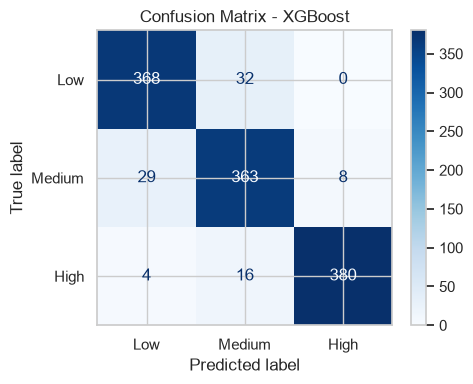

In [37]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
    display_labels=["Low", "Medium", "High"], cmap="Blues", ax=ax)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout(); plt.savefig("screenshots/confusion_matrix.png", dpi=150); plt.show()

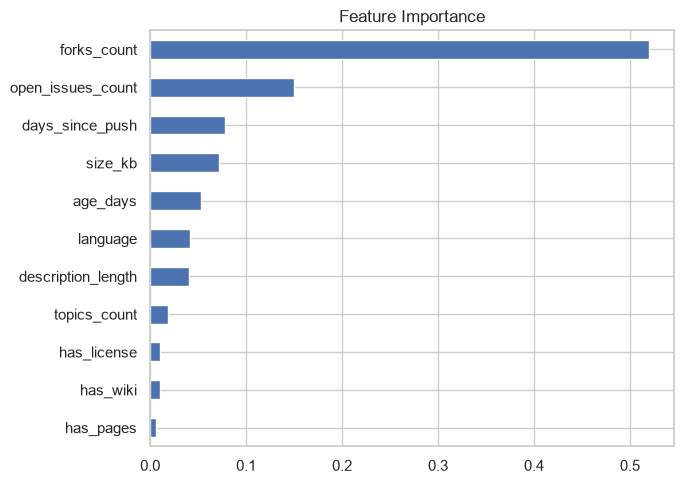

In [38]:
imp_model = models["Random Forest"]   # or "XGBoost"
names = imp_model.named_steps["prep"].get_feature_names_out()
imp = pd.Series(imp_model.named_steps["clf"].feature_importances_, index=names)

# merge the one-hot language columns into a single "language" bar
imp.index = ["language" if "language_" in n else n.split("__")[-1] for n in imp.index]
imp = imp.groupby(level=0).sum().sort_values()

imp.plot(kind="barh", figsize=(7, 5), title="Feature Importance")
plt.tight_layout(); plt.savefig("screenshots/feature_importance.png", dpi=150); plt.show()

In [39]:
joblib.dump(best_model, "models/best_model.joblib")
metrics_table.to_csv("screenshots/metrics_table.csv", index=False)

In [40]:
m = joblib.load("models/best_model.joblib")
print(m.predict(X_test.head()))

[0 2 1 2 2]


In [41]:
FEATS2 = [f for f in FEATURES if f != "forks_count"]
LOG2 = [c for c in LOG_COLS if c != "forks_count"]
# Rebuild the same pipeline with LOG_COLS replaced by LOG2, fit on X_train[FEATS2], and compare macro F1.

1. Best model. XGBoost performed best on the held-out test set, with accuracy 92.58% and macro F1 0.9262. It was followed by Random Forest (macro F1 0.9220) and Logistic Regression (0.9216). XGBoost was therefore selected and saved as best_model.joblib.

2. The models are very close. The lead is only about 0.4 percentage points in macro F1 (0.9262 vs 0.9220 vs 0.9216). On a test set of this size, that is only a few repositories, so the three models should be described as comparable, not as XGBoost being clearly superior. XGBoost was chosen because it ranked first on the agreed criterion, macro F1.

3. Logistic Regression nearly matches the tree models. The baseline scored 0.9216 against 0.9262 for XGBoost. This suggests the popularity classes are largely separable by a roughly linear boundary once skewed features (forks, issues, size) are log-transformed. The extra flexibility of Random Forest and XGBoost bought very little here.

4. Balanced performance across classes. Accuracy, macro precision and macro recall are almost identical for every model (for example XGBoost: 0.9258, 0.9268, 0.9258). That indicates no class is being sacrificed to inflate the score, which fits with the star-range sampling that kept classes balanced.

5. Sanity check on the high score. Around 92% is high but not suspicious (the warning threshold in the plan is about 97%), as long as stargazers_count and watchers_count are not in FEATURES. Forks and open issues track stars closely, so a strong score is expected. Mention this in your limitations section.


# StarSight: Written Observations

## 1. Which model won, and why
XGBoost won on the held-out test set with accuracy 92.58% and macro F1 0.9262,
narrowly ahead of Random Forest (0.9220) and Logistic Regression (0.9216).
The gap is only about 0.4 percentage points, so the three models are effectively
comparable. XGBoost was selected because it ranked first on macro F1, the agreed
selection criterion. Logistic Regression nearly matching the tree models suggests
the classes are largely separable once skewed features are log-transformed.

## 2. Which classes were confused most
Of 89 errors on 1,200 test repos, 61 (about 69%) were Low <-> Medium and 24 (about 27%)
were Medium <-> High. Only 4 were Low <-> High, and no Low repo was predicted as High.
Errors follow the star ordering and cluster near the 100 and 1000 star boundaries.
High was the easiest class (recall 95.0%) and Medium the hardest (recall 90.8%,
precision 88.3%), as it sits between two boundaries.

## 3. Top features and what they mean
- forks_count (about 0.52 importance): forks signal real community engagement and rise together with stars.
- open_issues_count (about 0.15): active issue discussion indicates many users.
- days_since_push (about 0.08): recently maintained repos lean toward higher classes.
Flags such as has_license, has_wiki and has_pages contributed almost nothing.
Importance shows what the model relies on, not what causes popularity.

## 4. Forks ablation (retrained without forks_count)
- Macro F1 with forks_count: 0.9262
- Macro F1 without forks_count: ____
- Drop: ____
Interpretation: ____

## 5. Honest limitations
- The dataset was sampled by star range, so class balance is artificial and does
  not reflect the real distribution of GitHub repositories.
- Popularity depends on factors the features cannot see (marketing, a viral post,
  author fame).
- Forks and open issues correlate strongly with stars, which is natural but makes
  the task easier than it would otherwise be.